In [27]:
import numpy as np
import matplotlib.pyplot as plt

## Monomi in $\R$

I monomi nella variabile $x$ sono le seguenti funzioni reali a valori reali

$$ 1,x,x^2,\dots,x^s,\dots $$

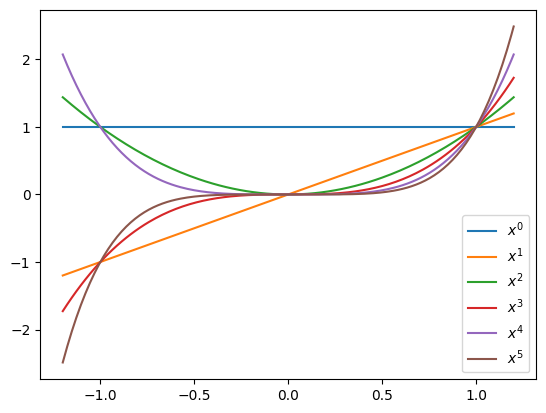

In [28]:
# Creiamo un vettore di 200 punti equispaziati nell'intervallo [-1.2, 1.2].
# Questo vettore rappresenta le ascisse (asse x) su cui valuteremo i monomi.
x = np.linspace(-1.2, 1.2, num=200)

# Numero massimo del grado dei monomi che vogliamo disegnare.
# Disegneremo i monomi da grado 0 fino a grado N.
N = 5

# Lista che conterrà le etichette da mostrare nella legenda del grafico.
leg = []

# Ciclo sui gradi dei monomi: 0, 1, ..., N
for i in range(N + 1):
    
    # Calcoliamo il valore del monomio x^i su tutti i punti del vettore x.
    # Il risultato è un vettore y della stessa dimensione di x.
    y = x ** i
    
    # Disegniamo il grafico della funzione y = x^i.
    # Ogni iterazione aggiunge una nuova curva al grafico.
    plt.plot(x, y)
    
    # Creiamo l'etichetta corrispondente al monomio corrente.
    # Verrà usata nella legenda per distinguere le curve.
    leg.append(f'$x^{i}$')

# Aggiungiamo la legenda al grafico con tutte le etichette raccolte.
plt.legend(leg)

# Visualizziamo il grafico finale.
plt.show()

## Polinomi in $\R$

Un polinomio è una funzione da $\R$ in $\R$ che si può scrivere come una combinazione lineare (somma pesata) di un numero finito di monomi

$$ p(x) = a_0+a_1x+a_2x^2+\dots+a_nx^n $$

I numeri reali $a_0,a_1,\dots,a_n$ sono i coefficienti del polinomio e lo individuano in modo univoco.

L'esponente del monomio di grado più alto determina il grado del polinomio.

**Esempio**: costruzione del grafico del polinomio di grado 2
$$p(x) = 1 + 4x - 2x^2$$
nell'intervallo $[-1,4]$

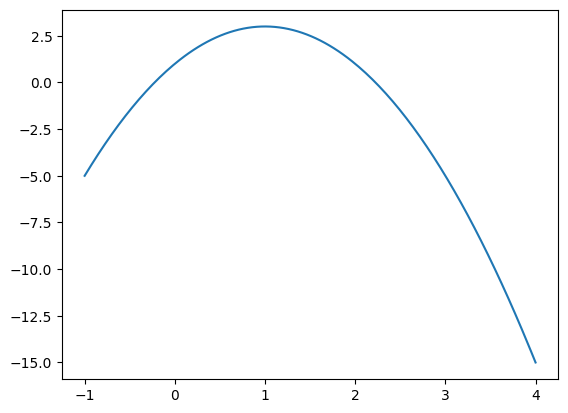

In [29]:
# Creiamo un vettore di 200 punti equispaziati nell'intervallo [-1, 4].
# Questo vettore rappresenta le ascisse (asse x) su cui valuteremo il polinomio.
x = np.linspace(-1,4,num=200)

# Definiamo la funzione polinomiale.
y = 1 + 4*x - 2*x**2

# Disegniamo e visualizziamo il grafico finale.
plt.plot(x,y)
plt.show()

**Esempio**: costruzione del grafico del polinomio di grado 4
$$p(x) = 1.5 -x + 3x^2 - 4x^3 +0.8x^4$$
nell'intervallo $[-1,4]$

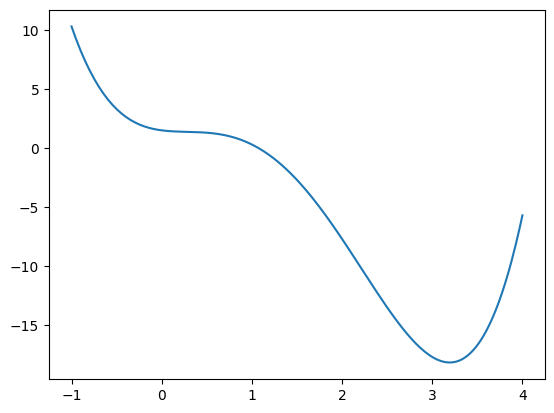

In [30]:
# Creiamo un vettore di 200 punti equispaziati nell'intervallo [-1, 4].
x = np.linspace(-1,4,num=200)

# Definiamo la funzione polinomiale.
p = 1.5 - x + 3*x**2 - 4*x**3 + 0.8*x**4

# Disegniamo e visualizziamo il grafico del polinomio.
plt.plot(x,p)
plt.show()

## Algoritmi per valutare un polinomio

### **Algoritmo "naif"**

In [31]:
def pol_val0(a, x):
    """
    Valutazione "naif" di un polinomio.

    INPUT:
    - a : array numpy contenente i coefficienti del polinomio
          a[0] + a[1]x + a[2]x^2 + ... + a[n]x^n
    - x : array numpy dei punti in cui valutare il polinomio

    OUTPUT:
    - p : array numpy contenente i valori del polinomio nei punti x
    """

    # Numero di coefficienti del polinomio (grado = n-1).
    n = a.size

    # Inizializziamo il vettore dei risultati a zero.
    # Ha la stessa forma di x (così possiamo lavorare vettorialmente).
    p = np.zeros(x.shape)

    # Sommiamo i contributi dei vari termini del polinomio:
    # a[i] * x^i
    for i in range(n):
        # x**i calcola tutte le potenze i-esime degli elementi di x.
        # a[i] è il coefficiente associato.
        p += a[i] * (x ** i)

    return p

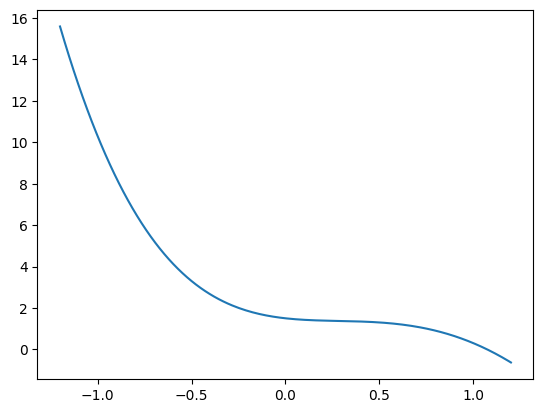

In [32]:
# =======================
# ESEMPIO DI UTILIZZO
# =======================

# Definiamo i coefficienti del polinomio:
# p(x) = 1.5 - x + 3x^2 - 4x^3 + 0.8x^4
a = np.array([1.5, -1, 3, -4, 0.8])

# Creiamo un vettore di 200 punti equispaziati nell'intervallo [-1.2, 1.2].
x = np.linspace(-1.2, 1.2, 200)

# Calcoliamo i valori del polinomio nei punti x.
q = pol_val0(a, x)

# Disegniamo e mostriamo il grafico del polinomio.
plt.plot(x, q)
plt.show()

### Complessità computazionale

Per calcolare la complessità computazionale dell'algoritmo "naif" precedente si deve tenere conto del fatto che la potenza $x^i$ richiede $i-1$ prodotti.

In totale, per calcolare un polinomio di grado $n$ in un singolo punto $x$, l'algoritmo "naif" richiede almeno
$$ 2 + 3 + ... + n-1\simeq \frac{n(n-1)}{2}$$
prodotti.

La complessità di questo algoritmo è maggiore di quanto necessario.

Una prima riduzione della compessità si ottiene tenendo conto che $x^i = (x^{i-1})\cdot x$, ossia, avendo già calcolato $x^{i-1}$, la potenza successiva si ottiene con un solo prodotto moltiplicando per $x$.

### **Algoritmo "naif" migliorato**

In [33]:
def pol_val1(a, x):
    """
    Valutazione "naif migliorata" di un polinomio.

    INPUT:
    - a : array numpy contenente i coefficienti del polinomio
          a[0] + a[1]x + a[2]x^2 + ... + a[n]x^n
    - x : array numpy dei punti in cui valutare il polinomio

    OUTPUT:
    - p : array numpy contenente i valori del polinomio nei punti x

    IDEA: Invece di calcolare ogni volta x**i (costoso), costruiamo 
    iterativamente le potenze di x: x^1, x^2, x^3, ...
    """

    # Numero di coefficienti.
    n = a.size

    # Inizializziamo il risultato con il termine costante.
    p = a[0]

    # Variabile che conterrà progressivamente:
    # x^1, x^2, x^3, ...
    s = 1

    # Partiamo da i = 1 perché a[0] è già stato considerato.
    for i in range(1, n):
        
        # Aggiorniamo la potenza: s = x^i
        # (moltiplichiamo per x ad ogni iterazione).
        s = s * x

        # Aggiungiamo il termine a[i] * x^i.
        p = p + a[i] * s

    return p

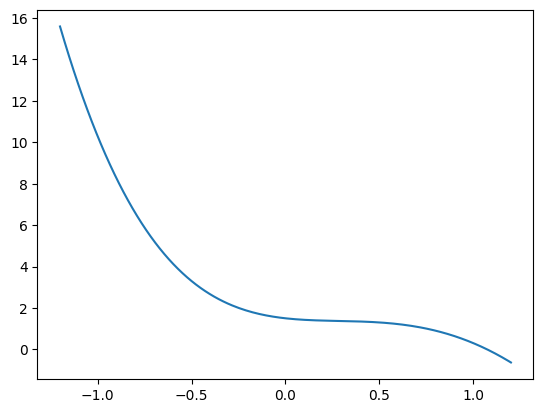

In [34]:
# =======================
# ESEMPIO DI UTILIZZO
# =======================

# p(x) = 1.5 - x + 3x^2 - 4x^3 + 0.8x^4
a = np.array([1.5, -1, 3, -4, 0.8])

# Punti di valutazione.
x = np.linspace(-1.2, 1.2, 200)

# Calcolo del polinomio.
q = pol_val1(a, x)

# Grafico
plt.plot(x, q)
plt.show()

La complessità dell'algoritmo "naif migliorato" è di $n$ somme e $2n$ prodotti, per il calcolo di un polinomio di grado $n$ in un punto.

### **Algoritmo di Horner**

La complessità dell'algoritmo di valutazione di un polinomio può essere ulteriormente ridotta per quanto riguarda i prodotti, utilizzando l'*algoritmo di Horner*.

Questo algoritmo organizza il calcolo mediante raccoglimenti successivi

Esempio:
$$\begin{array}{lcl}
p_4(x) &=& a_0+a_1x+2_2x^2+a_3x^3+a_4x^4\\
&=& a_0 + (a_1+a_2x+a_3x^2+a_4x^3)\cdot x\\
&=& a_0 + (a_1 + (a_2 + a_3x +a_4x^2)\cdot x)\cdot x\\
&=&a_0+(a_1+(a_2+(a_3 +a_4x)\cdot x)\cdot x)\cdot x \\
&=&a_0+(a_1+(a_2+(a_3 +(a_4)\cdot x)\cdot x)\cdot x)\cdot x
\end{array}$$

L'algoritmo inizia dalla parentesi più interna e prosegue moltiplicando il valore della parentesi per $x$ e sommando il coefficiente precedente.

La complessità dell'algoritmo di Horner è di $n$ somme e $n$ prodotti (la metà rispetto al metodo "naif" migliorato).

In [39]:
def pol_val_horner(a, x):
    """
    Valutazione di un polinomio tramite lo schema di Horner.

    INPUT:
    - a : array numpy dei coefficienti del polinomio
          p(x) = a[0] + a[1]x + a[2]x^2 + ... + a[n]x^n
    - x : array numpy dei punti in cui valutare il polinomio

    OUTPUT:
    - p : array numpy con i valori del polinomio nei punti x

    IDEA (Schema di Horner):
    Riscriviamo il polinomio in forma annidata:

    p(x) = a[0] + x(a[1] + x(a[2] + x(... + x(a[n]))...))

    Questo permette di:
    - ridurre il numero di operazioni
    - evitare il calcolo esplicito delle potenze
    - migliorare la stabilità numerica
    """

    # Numero di coefficienti
    n = a.size

    # Iniziamo dall'ultimo coefficiente (grado massimo)
    p = a[n - 1]

    # Cicliamo all'indietro: a[n-2], a[n-3], ..., a[0]
    for i in range(n - 2, -1, -1):
        
        # Ad ogni passo "incapsuliamo" il risultato:
        # p = a[i] + x * (valore precedente)
        p = a[i] + p * x

    return p

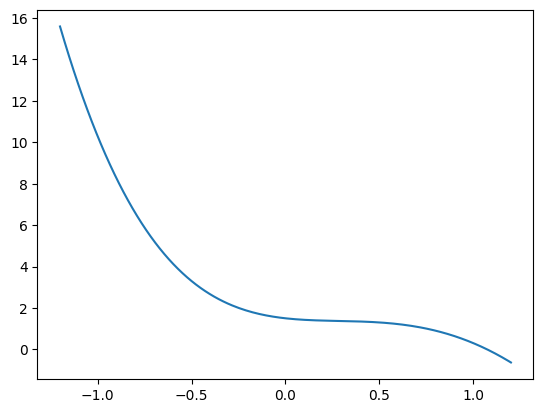

In [ ]:
# =======================
# ESEMPIO DI UTILIZZO
# =======================

# p(x) = 1.5 - x + 3x^2 - 4x^3 + 0.8x^4
a = np.array([1.5, -1, 3, -4, 0.8])

# Punti di valutazione
x = np.linspace(-1.2, 1.2, 200)

# Calcolo con Horner
h = pol_val_horner(a, x)

# Grafico
plt.plot(x, h)
plt.show()

L'algoritmo di Horner è implementato nella funzione di NumPy
`polyval(b,x)`, che tuttavia richiede i coefficienti del polinomio in ordine inverso, secondo la notazione seguente
$$p(x) = b_0x^n+b_1x^{n-1} + ...+b_{n-1}x+b_n $$

La documentazione si trova [qui](https://numpy.org/doc/stable/reference/generated/numpy.polyval.html)



[ 1.5 -1.   3.  -4.   0.8]
[ 0.8 -4.   3.  -1.   1.5]


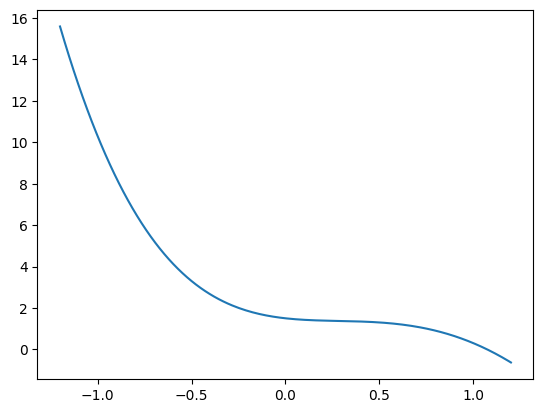

In [45]:
# Mostra inversione dell'ordine dei coefficienti.
print(a)
print(a[-1::-1])

# Calcolo con il metodo di Horner definito in numpy
# (con inversione dell'ordine dei coefficienti)
z = np.polyval(a[-1::-1],x)

# Grafico
plt.plot(x,z)
plt.show()